In [4]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV
import scipy.stats as stats
from sklearn.model_selection import RandomizedSearchCV
from matplotlib import pyplot as plt
from Helpers.data_set_cleaner import import_amazon_reviews_csv_file, amazon_reviews_split
from Helpers.text_processor import TextProcessor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import spacy
from pandas import Series
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

True

# Definicje

In [5]:
nlp = spacy.load("en_core_web_sm")
base_stop_words = set(stopwords.words('english'))
sentiment_whitelist = {
    'no', 'not', 'nor', 'but', 'against', 'too', 'very',
    'don', "don't", 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't",
    'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't",
    'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't",
    'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't",
    'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}
custom_stop_words = base_stop_words - sentiment_whitelist


def preprocess_single_remove_default_stop_words(text: str) -> str:
    doc = nlp(text)
    tokens = [token.lemma_.lower() for token in doc if not token.is_stop]
    return " ".join(tokens)


def preprocess_single_no_stop_words(text: str) -> str:
    doc = nlp(text)
    tokens = [token.lemma_.lower() for token in doc]
    return " ".join(tokens)


def preprocess_single_remove_custom_stop_words(text: str) -> str:
    doc = nlp(text)
    tokens = [token.lemma_.lower() for token in doc if token.lemma_.lower() not in custom_stop_words]
    return " ".join(tokens)


def preprocess_series(text_series: Series, preprocess_single) -> Series:
    return text_series.apply(preprocess_single)

# Testy

In [6]:
path = r".\..\Data\train.csv"
df = import_amazon_reviews_csv_file(path, 2000)
X_raw, y = amazon_reviews_split(df)

etykiety = ['Negative', 'Neutral', 'Positive']

model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_df=0.8, min_df=3)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C = 1.0))
])

X_processed = preprocess_series(X_raw, preprocess_single_remove_default_stop_words)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

model_pipeline.fit(X_train, y_train)
predictions = model_pipeline.predict(X_test)
cm_default = confusion_matrix(y_test, predictions, labels=etykiety)
print("[REMOVE DEFAULT STOP WORDS]")
print(classification_report(y_test, predictions))
#---------------------------------------------------------------



X_processed = preprocess_series(X_raw, preprocess_single_remove_custom_stop_words)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

model_pipeline.fit(X_train, y_train)
predictions = model_pipeline.predict(X_test)
cm_custom = confusion_matrix(y_test, predictions, labels=etykiety)
print("[REMOVE CUSTOM STOP WORDS]")
print(classification_report(y_test, predictions))
#---------------------------------------------------------------



X_processed = preprocess_series(X_raw, preprocess_single_no_stop_words)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_df=0.8, min_df=3)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C = 1.0))
])

model_pipeline.fit(X_train, y_train)
predictions = model_pipeline.predict(X_test)
cm_no = confusion_matrix(y_test, predictions, labels=etykiety)
print("[DONT REMOVE STOP WORDS]")
print(classification_report(y_test, predictions))


[REMOVE DEFAULT STOP WORDS]
              precision    recall  f1-score   support

    Negative       0.62      0.68      0.65       152
     Neutral       0.36      0.38      0.37        82
    Positive       0.74      0.66      0.70       166

    accuracy                           0.61       400
   macro avg       0.58      0.57      0.57       400
weighted avg       0.62      0.61      0.61       400

[REMOVE CUSTOM STOP WORDS]
              precision    recall  f1-score   support

    Negative       0.69      0.71      0.70       152
     Neutral       0.42      0.46      0.44        82
    Positive       0.77      0.72      0.74       166

    accuracy                           0.66       400
   macro avg       0.63      0.63      0.63       400
weighted avg       0.67      0.66      0.67       400

[DONT REMOVE STOP WORDS]
              precision    recall  f1-score   support

    Negative       0.71      0.80      0.75       152
     Neutral       0.46      0.41      0.44      

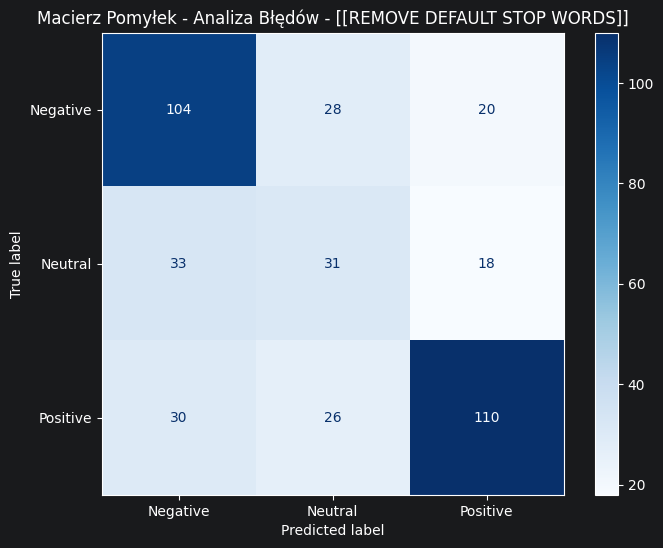

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=etykiety)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Macierz Pomyłek - Analiza Błędów - [[REMOVE DEFAULT STOP WORDS]]")
plt.show()

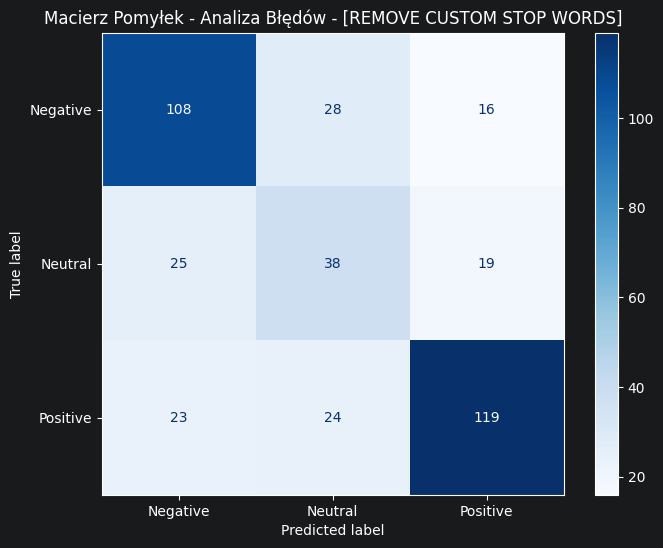

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=etykiety)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Macierz Pomyłek - Analiza Błędów - [REMOVE CUSTOM STOP WORDS]")
plt.show()

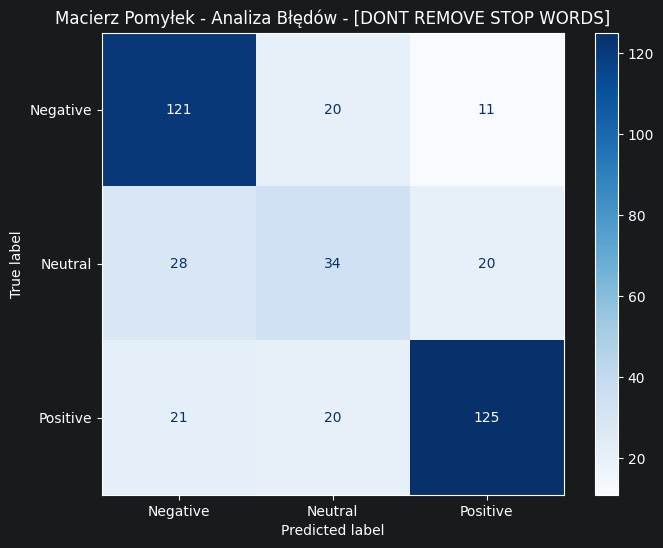

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_no, display_labels=etykiety)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Macierz Pomyłek - Analiza Błędów - [DONT REMOVE STOP WORDS]")
plt.show()